In [63]:
#Importation des bibliothéques
!pip install wordcloud
!pip install nltk
!pip install pandas nltk scikit-learn
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import nltk
import re
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
from nltk.corpus import wordnet
from nltk.stem.snowball import SnowballStemmer
import torch
import os
import json
!pip install unsloth
!pip install datasets
!pip install trl
from datasets import load_dataset
from huggingface_hub import notebook_login
from transformers import TrainingArguments
from trl import SFTTrainer
!pip install langchain
!pip install ctransformers
!pip install ctransformers[cuda]
from transformers import AutoModelForCausalLM, AutoTokenizer
!pip install langchain-community  # Install the missing package
import os
from langchain.llms import LlamaCpp
from langchain import PromptTemplate, LLMChain
from langchain.callbacks.manager import CallbackManager
from langchain.callbacks.streaming_stdout import StreamingStdOutCallbackHandler
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.multioutput import MultiOutputClassifier
from sklearn.metrics import classification_report


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [64]:
#Importation de data csv
file_path = r"/content/helpdesk_customer_tickets.csv"
data = pd.read_csv(file_path)
data.head()
print(data.columns)

Index(['id', 'subject', 'body', 'answer', 'type', 'queue', 'priority',
       'language', 'business_type', 'tag_1', 'tag_2', 'tag_3', 'tag_4',
       'tag_5', 'tag_6', 'tag_7', 'tag_8', 'tag_9'],
      dtype='object')


préparation de la data

In [65]:
df_cleaned = data.drop(columns=['tag_9','tag_8','tag_7','tag_6','tag_5','tag_4'])

In [66]:
df_cleaned['subject'].fillna('Unknown', inplace=True)

<ipython-input-66-49c9f48cebf0>:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_cleaned['subject'].fillna('Unknown', inplace=True)


In [67]:
tags_columns = ['tag_1', 'tag_2', 'tag_3']
df_cleaned[tags_columns] = df_cleaned[tags_columns].fillna('No Tag')

In [68]:
df_cleaned['language'] = df_cleaned['language'].str.lower()
df_cleaned['priority'] = df_cleaned['priority'].str.lower()

In [69]:
df_cleaned.head()

,id,subject,body,answer,type,queue,priority,language,business_type,tag_1,tag_2,tag_3
0,36,Anfrage zu den Spezifikationen und Anpassungso...,Sehr geehrtes Support-Team des Tech Online Sto...,"Sehr geehrter <name>,\n\nvielen Dank für Ihr I...",Request,Customer Service,medium,de,Tech Online Store,Product Support,Sales Inquiry,Technical Guidance
1,39,Déconnexions fréquentes et plantages,Le client signale des déconnexions fréquentes ...,Nous allons enquêter sur le problème avec Zoom...,Incident,Product Support,high,fr,Software Development Company,Technical Support,Software Bug,Service Disruption
2,243,Problema de sonido Dell XPS,"Problema con el sonido, manejando como devoluc...",Gracias por su correo electrónico. Procesaremo...,Problem,Returns and Exchanges,medium,es,Tech Online Store,Returns and Exchanges,Product Support,Customer Service
3,381,Assistance requise pour la configuration du ta...,"Cher support client,\n\nNotre client, <name>, ...","Cher <name>,\n\nMerci de nous avoir contactés....",Request,Product Support,medium,fr,Software Development Company,Technical Support,Product Support,General Inquiry
4,663,Urgente: Assistência Imediata Necessária para ...,Caro Suporte ao Cliente da Firma de Consultori...,"Caro Cliente,\n\nRecebemos sua solicitação urg...",Incident,Human Resources,medium,pt,IT Consulting Firm,Urgent Issue,Payroll Issue,Technical Support


In [70]:
# garder que la data en français ou en anglais
df_cleaned = df_cleaned[df_cleaned['language'].isin(['fr', 'en'])]


In [71]:
df_cleaned.head()

,id,subject,body,answer,type,queue,priority,language,business_type,tag_1,tag_2,tag_3
1,39,Déconnexions fréquentes et plantages,Le client signale des déconnexions fréquentes ...,Nous allons enquêter sur le problème avec Zoom...,Incident,Product Support,high,fr,Software Development Company,Technical Support,Software Bug,Service Disruption
3,381,Assistance requise pour la configuration du ta...,"Cher support client,\n\nNotre client, <name>, ...","Cher <name>,\n\nMerci de nous avoir contactés....",Request,Product Support,medium,fr,Software Development Company,Technical Support,Product Support,General Inquiry
6,717,Unknown,"Dear Tech Online Store Customer Support,\n\nI ...","Dear <name>,\n\nThank you for contacting Tech ...",Problem,Returns and Exchanges,low,en,Tech Online Store,Technical Support,Product Support,Returns and Exchanges
7,900,Frequent Disconnections and Crashes,Customer reports frequent disconnections and c...,We'll investigate the issue with Zoom 5.11.0. ...,Incident,Product Support,high,en,Software Development Company,Technical Support,Service Disruption,Network Issue
9,1032,Urgent: Immediate Assistance Required for Serv...,"Dear IT Services Customer Support, \n\nOur ser...","Dear <name>,\n\nThank you for contacting IT Se...",Problem,Technical Support,high,en,IT Services,Technical Support,IT Support,Urgent Issue


nettoyage des données


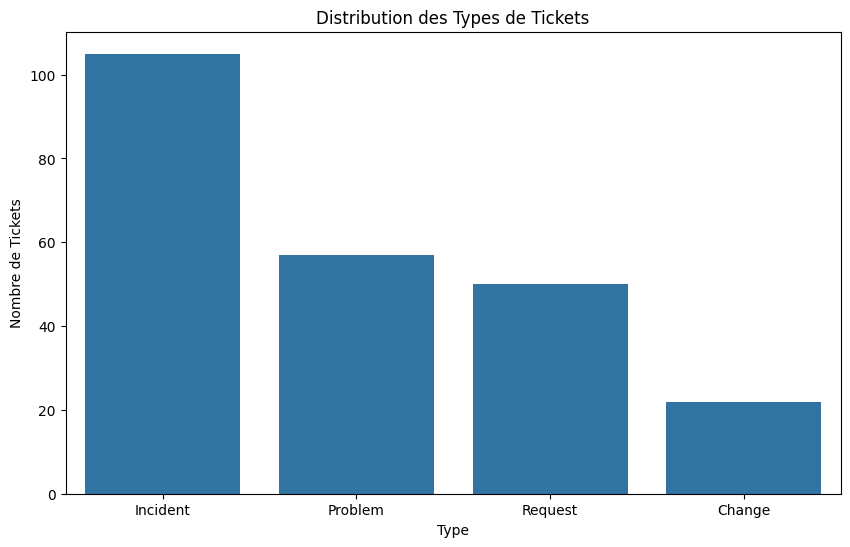

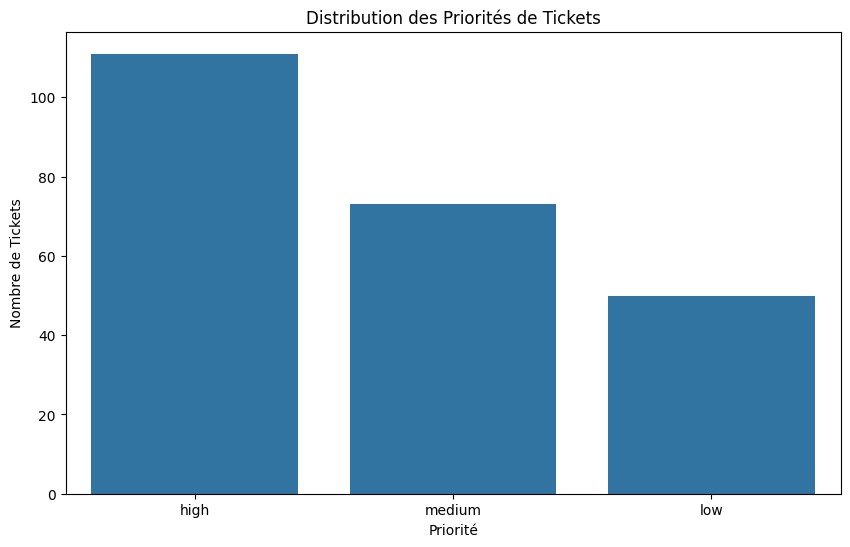

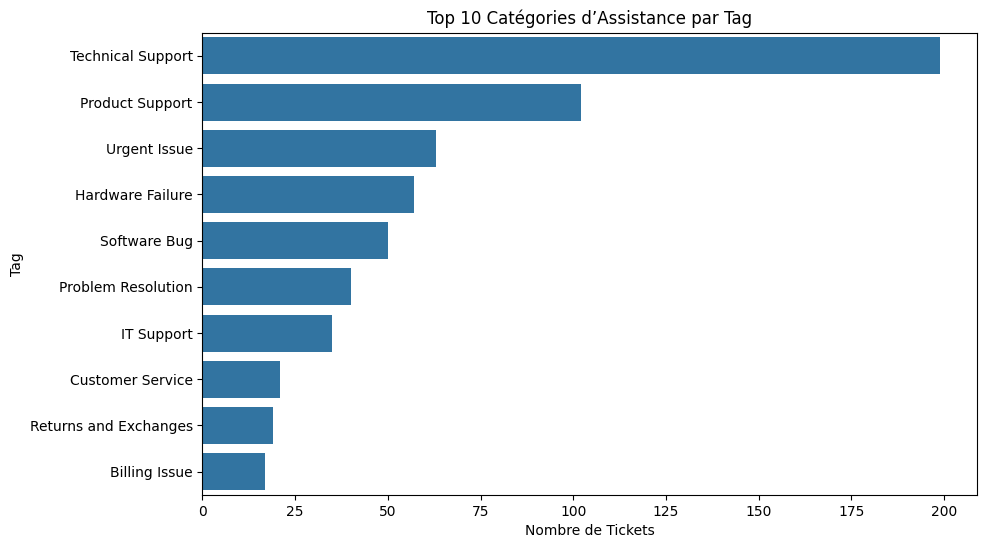

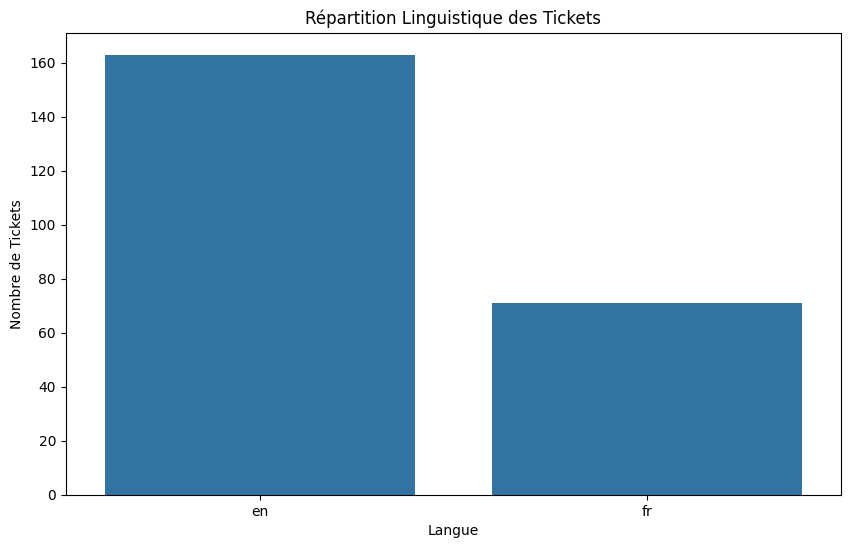

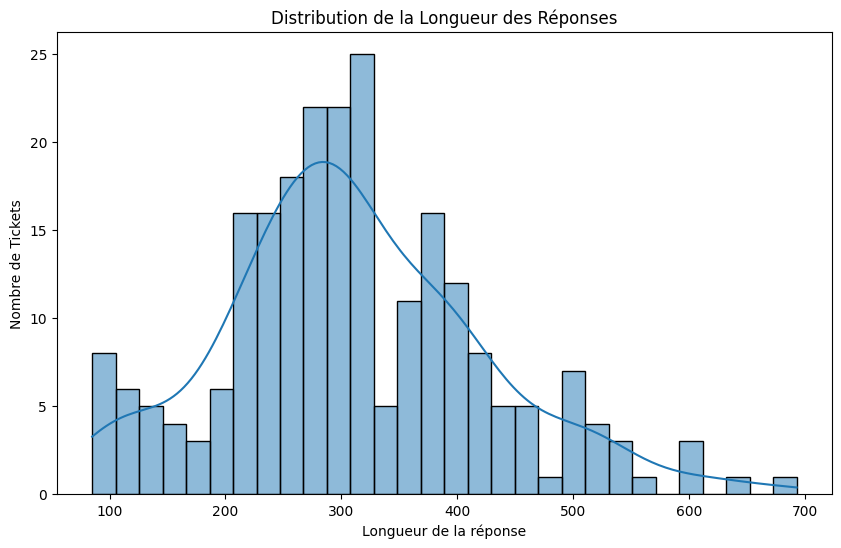

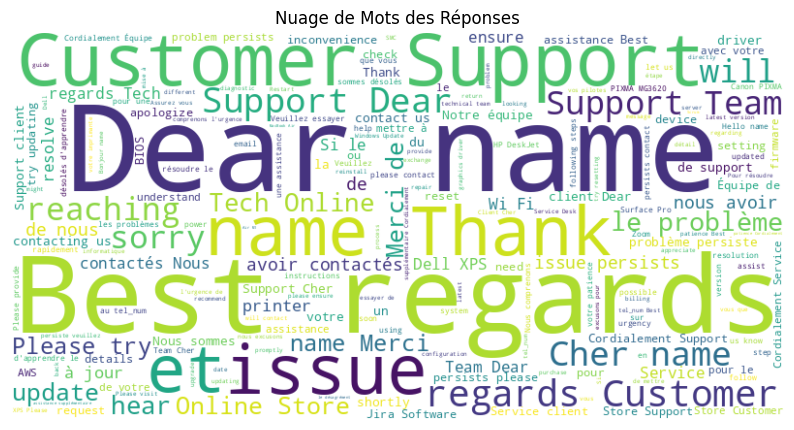

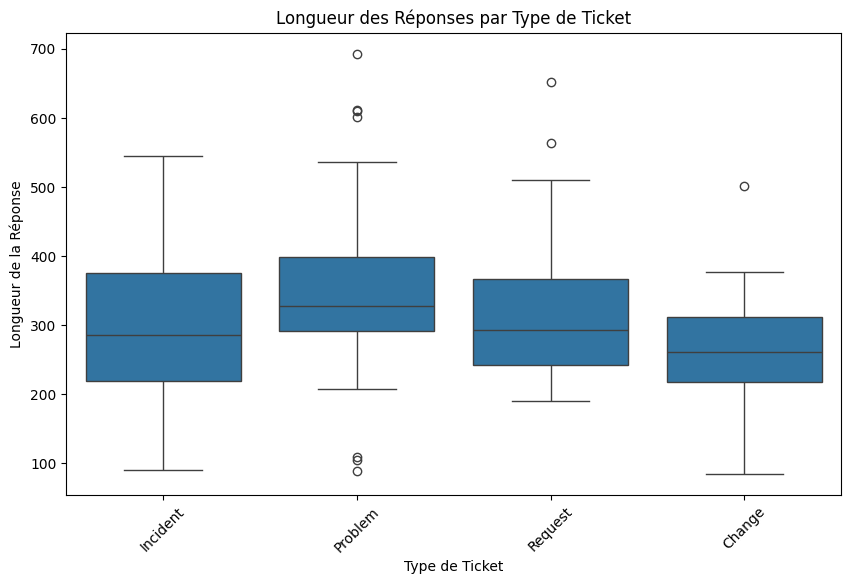

In [72]:
# 1. Distribution des types de tickets
plt.figure(figsize=(10, 6))
sns.countplot(data=df_cleaned, x='type', order=df_cleaned['type'].value_counts().index)
plt.title('Distribution des Types de Tickets')
plt.xlabel('Type')
plt.ylabel('Nombre de Tickets')
plt.show()

# 2. Distribution des priorités de tickets
plt.figure(figsize=(10, 6))
sns.countplot(data=df_cleaned, x='priority', order=df_cleaned['priority'].value_counts().index)
plt.title('Distribution des Priorités de Tickets')
plt.xlabel('Priorité')
plt.ylabel('Nombre de Tickets')
plt.show()

# 3. Catégories d’assistance principales basées sur les tags
tags_columns = ['tag_1', 'tag_2', 'tag_3']
tags_data = df_cleaned[tags_columns].melt(value_name='tag').dropna()
plt.figure(figsize=(10, 6))
sns.countplot(data=tags_data, y='tag', order=tags_data['tag'].value_counts().index[:10])
plt.title('Top 10 Catégories d’Assistance par Tag')
plt.xlabel('Nombre de Tickets')
plt.ylabel('Tag')
plt.show()

plt.figure(figsize=(10, 6))
sns.countplot(data=df_cleaned, x='language', order=df_cleaned['language'].value_counts().index)
plt.title('Répartition Linguistique des Tickets')
plt.xlabel('Langue')
plt.ylabel('Nombre de Tickets')
plt.show()

df_cleaned['answer_length'] = df_cleaned['answer'].apply(len)
plt.figure(figsize=(10, 6))
sns.histplot(df_cleaned['answer_length'], bins=30, kde=True)
plt.title('Distribution de la Longueur des Réponses')
plt.xlabel('Longueur de la réponse')
plt.ylabel('Nombre de Tickets')
plt.show()

all_text = ' '.join(df_cleaned['answer'].dropna())
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_text)
plt.figure(figsize=(10, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.title("Nuage de Mots des Réponses")
plt.axis('off')
plt.show()

plt.figure(figsize=(10, 6))
sns.boxplot(data=df_cleaned, x='type', y='answer_length', order=df_cleaned['type'].value_counts().index)
plt.title("Longueur des Réponses par Type de Ticket")
plt.xlabel("Type de Ticket")
plt.ylabel("Longueur de la Réponse")
plt.xticks(rotation=45)
plt.show()

Suggestion des reponses

In [73]:
# Download 'punkt_tab' and 'stopwords' if not already present
nltk.download('punkt_tab')
nltk.download('stopwords')

#Normalize Text
def preprocess_text(text):
    # Convert to lowercase
    text = text.lower()
    # Remove punctuation
    text = re.sub(r'[^\w\s]', '', text)
    # Tokenize
    tokens = word_tokenize(text)
    # Remove stopwords
    tokens = [word for word in tokens if word not in stopwords.words('english')]
    return ' '.join(tokens)

# Apply the preprocessing function to the 'answer' column
df_cleaned['processed_answer'] = df_cleaned['answer'].apply(preprocess_text)

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [74]:
# Initialize lemmatizer
nltk.download('averaged_perceptron_tagger_eng')
lemmatizer = WordNetLemmatizer()

# Function to get the wordnet part of speech tag for lemmatization
def get_wordnet_pos(word):
    """Map POS tag to first character used by lemmatizer"""
    tag = nltk.pos_tag([word])[0][1][0].upper()
    tag_map = {'N': wordnet.NOUN, 'V': wordnet.VERB, 'R': wordnet.ADJ}
    return tag_map.get(tag, wordnet.NOUN)

# Normalize Text with Lemmatization
def preprocess_text_with_lemmatization(text):
    # Convert to lowercase
    text = text.lower()
    # Remove punctuation
    text = re.sub(r'[^\w\s]', '', text)
    # Tokenize
    tokens = word_tokenize(text)
    # Remove stopwords and lemmatize
    tokens = [lemmatizer.lemmatize(word, get_wordnet_pos(word)) for word in tokens if word not in stopwords.words('english')]
    return ' '.join(tokens)

# Apply the preprocessing function to the 'answer' column
df_cleaned['processed_answer'] = df_cleaned['answer'].apply(preprocess_text_with_lemmatization)


[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


In [75]:
# Inspect the data structure
print(df_cleaned.head())
print(df_cleaned.info())

# Check for missing values
print(df_cleaned.isnull().sum())


     id                                            subject  \
1    39               Déconnexions fréquentes et plantages   
3   381  Assistance requise pour la configuration du ta...   
6   717                                            Unknown   
7   900                Frequent Disconnections and Crashes   
9  1032  Urgent: Immediate Assistance Required for Serv...   

                                                body  \
1  Le client signale des déconnexions fréquentes ...   
3  Cher support client,\n\nNotre client, <name>, ...   
6  Dear Tech Online Store Customer Support,\n\nI ...   
7  Customer reports frequent disconnections and c...   
9  Dear IT Services Customer Support, \n\nOur ser...   

                                              answer      type  \
1  Nous allons enquêter sur le problème avec Zoom...  Incident   
3  Cher <name>,\n\nMerci de nous avoir contactés....   Request   
6  Dear <name>,\n\nThank you for contacting Tech ...   Problem   
7  We'll investigate the i

In [76]:
stop_words = set(stopwords.words('english','français'))  # Adjust language if needed
stemmer = SnowballStemmer("english",'français')

In [77]:
df_cleaned['subject_processed'] = df_cleaned['subject'].apply(lambda x: preprocess_text(x) if pd.notnull(x) else "")
df_cleaned['body_processed'] = df_cleaned['body'].apply(lambda x: preprocess_text(x) if pd.notnull(x) else "")

In [78]:
print(df_cleaned[['subject', 'subject_processed', 'body', 'body_processed']].head())

                                             subject  \
1               Déconnexions fréquentes et plantages   
3  Assistance requise pour la configuration du ta...   
6                                            Unknown   
7                Frequent Disconnections and Crashes   
9  Urgent: Immediate Assistance Required for Serv...   

                                   subject_processed  \
1               déconnexions fréquentes et plantages   
3  assistance requise pour la configuration du ta...   
6                                            unknown   
7                    frequent disconnections crashes   
9  urgent immediate assistance required server do...   

                                                body  \
1  Le client signale des déconnexions fréquentes ...   
3  Cher support client,\n\nNotre client, <name>, ...   
6  Dear Tech Online Store Customer Support,\n\nI ...   
7  Customer reports frequent disconnections and c...   
9  Dear IT Services Customer Support, \n\nOur 

In [79]:
# Charger le modèle Flan-T5
model_name = "google/flan-t5-base"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSeq2SeqLM.from_pretrained(model_name)

# Trouver les tickets les plus pertinents avec TF-IDF
def get_relevant_tickets(new_text, df_cleaned, top_n=5):
    """
    Identifie les tickets les plus similaires à une nouvelle demande.
    """
    vectorizer = TfidfVectorizer(stop_words='english', ngram_range=(1, 2))
    df_cleaned['text'] = df_cleaned['subject'].fillna("") + " " + df_cleaned['body'].fillna("")
    text_vectors = vectorizer.fit_transform(df_cleaned['text'])
    new_text_vector = vectorizer.transform([new_text])
    similarities = cosine_similarity(new_text_vector, text_vectors).flatten()
    top_indices = similarities.argsort()[-top_n:][::-1]
    return df_cleaned.iloc[top_indices], similarities[top_indices]

# Générer une réponse avec Flan-T5
def generate_response_with_llm(new_body, relevant_tickets, max_input_length=512, max_output_length=150):
    """
    Génère une réponse avec Flan-T5 basée sur l'historique pertinent.
    """
    # Construire le contexte pour le modèle
    context = ""
    for _, row in relevant_tickets.iterrows():
        context += f"Body: {row['body']}\nAnswer: {row['answer']}\n---\n"

    # Créer le prompt
    prompt = (
        f"Based on the following historical tickets:\n{context}\n\n"
        f"New Ticket:\n"
        f"Description: {new_body}\n\n"
        f"Please provide a concise and relevant response:"
    )

    # Tokenizer et génération
    inputs = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=max_input_length)
    outputs = model.generate(
        inputs["input_ids"],
        max_length=max_output_length,
        num_beams=5,
        temperature=0.7,
        repetition_penalty=1.2
    )
    return tokenizer.decode(outputs[0], skip_special_tokens=True)

# Fonction principale
def generate_combined_response(new_subject, new_body, df_cleaned, threshold=0.2):
    """
    Combine la recherche directe et la génération de réponse avec LLM.
    """
    new_text = new_subject + " " + new_body

    # Récupérer les tickets pertinents
    relevant_tickets, similarities = get_relevant_tickets(new_text, df_cleaned)

    # Vérifier le score de similarité du ticket le plus pertinent
    if similarities[0] > threshold:
        # Réponse directe basée sur l'historique
        direct_response = relevant_tickets.iloc[0]['answer']
        return f"Direct response: {direct_response}"
    else:
        # Réponse générée par Flan-T5
        generated_response = generate_response_with_llm(new_body, relevant_tickets)
        return f"Generated response: {generated_response}"

In [80]:
# Exemple d'utilisation
new_subject = "Printer issue"
new_body = "My printer is not working."
response = generate_combined_response(new_subject, new_body, df_cleaned)
print(response)

Direct response: Dear <name>,

Thank you for contacting us. We're sorry to hear about the connectivity issues with your Canon PIXMA MG3620 printer following the firmware update. Please try the following steps:
1. Confirm that your WiFi password is correct.
2. Ensure the printer is within range of the WiFi signal.
3. Reinstall the printer drivers.

If the issue continues, please contact Canon support directly. 

Sincerely,
Service Desk Team


In [81]:
# Exemple d'utilisation
new_subject = "Zoom issue"
new_body = "Zoom is not working."
response = generate_combined_response(new_subject, new_body, df_cleaned)
print(response)

Direct response: Dear <name>, please update Zoom to the latest version and ensure a stable internet connection during webinars. If issues persist, try using an alternative device or contact Zoom support directly.

Best regards,
Support Team


In [82]:
# Exemple d'utilisation
new_subject = "Problème sur le pc"
new_body = "mon ordinateur ne s'allume plus"
response = generate_combined_response(new_subject, new_body, df_cleaned)
print(response)

Direct response: Cher <name>,
Essayez ces étapes : 1. Débranchez tous les périphériques. 2. Maintenez le bouton d'alimentation enfoncé pendant 15 à 20 secondes. 3. Connectez le chargeur et essayez de l'allumer. Si le problème persiste, veuillez nous contacter.

Cordialement,
L'équipe de support du Tech Online Store


**II. Classification des tickets**

In [83]:
# Préparation des données
def prepare_data(df_cleaned):
    """
    Prépare les données pour la classification.
    Args:
        df_cleaned (pd.DataFrame): DataFrame contenant les colonnes 'subject', 'type', 'priority', etc.
    Returns:
        X, Y: Features et labels.
    """
    # Features (input)
    X = df_cleaned['subject'].fillna("")

    # Labels (output)
    Y = df_cleaned[['type', 'priority', 'business_type', 'tag_1', 'tag_2', 'tag_3']].fillna("unknown")

    return X, Y

# Vectorisation des sujets
def vectorize_subjects(X):
    vectorizer = TfidfVectorizer(stop_words='english', max_features=5000)
    X_vectors = vectorizer.fit_transform(X)
    return vectorizer, X_vectors

# Entraînement du modèle
def train_classifier(X_vectors, Y):
    """
    Entraîne un modèle MultiOutputClassifier pour prédire plusieurs colonnes.
    """
    classifier = MultiOutputClassifier(RandomForestClassifier(random_state=42, n_estimators=100))
    classifier.fit(X_vectors, Y)
    return classifier

# Fonction de prédiction et d'affichage des résultats lisibles
def classify_ticket(subject, vectorizer, classifier):
    """
    Prédit la classification d'un nouveau ticket et affiche les résultats sous forme lisible.
    """
    subject_vector = vectorizer.transform([subject])
    prediction = classifier.predict(subject_vector)

    # Retourner les résultats sous forme lisible
    result = {
        "Type de ticket": prediction[0][0],
        "Priorité": prediction[0][1],
        "Business Type": prediction[0][2],
        "Tag 1": prediction[0][3],
        "Tag 2": prediction[0][4],
        "Tag 3": prediction[0][5]
    }

    return result

In [84]:
# Préparer les données
X, Y = prepare_data(df_cleaned)

# Vectoriser les données
vectorizer, X_vectors = vectorize_subjects(X)

# Diviser les données en train/test
X_train, X_test, Y_train, Y_test = train_test_split(X_vectors, Y, test_size=0.2, random_state=42)

# Entraîner le modèle
classifier = train_classifier(X_train, Y_train)

In [85]:
# Prédire pour un nouveau ticket
new_subject = "Printer is malfunctioning"
result = classify_ticket(new_subject, vectorizer, classifier)
# Afficher les résultats
print("Classification Result:")
for key, value in result.items():
    print(f"{key}: {value}")

Classification Result:
Type de ticket: Incident
Priorité: high
Business Type: Tech Online Store
Tag 1: Technical Support
Tag 2: Product Support
Tag 3: Problem Resolution


In [86]:
new_subject = "demande assistance pour configurer le poste"
result = classify_ticket(new_subject, vectorizer, classifier)
# Afficher les résultats
print("Classification Result:")
for key, value in result.items():
    print(f"{key}: {value}")

Classification Result:
Type de ticket: Request
Priorité: medium
Business Type: Tech Online Store
Tag 1: Technical Support
Tag 2: Product Support
Tag 3: Problem Resolution
